<center>

__Modelación del Aprendizaje con Inteligencia Artificial__

_GPO 302_

Examen


Prof. Jorge Adolfo Ramírez Uresti




Diego A. Parra Ruíz - - - A01801026
</center>

# Improtación de Librerías

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Métricas y Partición
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Árbol de Decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

# K-Means
import plotly.express as px
from sklearn.cluster import KMeans




# Importación del Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#df = pd.read_csv('') #Solo si usarás Drive
df = pd.read_csv("Data/Obesity.csv")

In [ ]:
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


# Limpieza del Dataset

In [ ]:
df.isna().sum() #Se limpian todos los valores que pudiese haber estado nulos
df.dropna()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,0.000000,1.000000,no,Public_Transportation,Normal_Weight
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,3.000000,yes,3.000000,0.000000,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,2.000000,no,2.000000,1.000000,Frequently,Public_Transportation,Normal_Weight
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,2.000000,no,2.000000,0.000000,Frequently,Walking,Overweight_Level_I
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,2.000000,no,0.000000,0.000000,Sometimes,Public_Transportation,Overweight_Level_II
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III


In [ ]:
replace = {'yes': 1, 'no':0, 'Male':1, 'Female':0} # Se reemplaza la información binaria
df = df.replace(replace)

df.drop(columns=['CAEC', 'CALC', 'MTRANS'], inplace=True) #Se remueven las variables categóricas y sus respectivas columnas
df.head()

<ipython-input-14-3947755056>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(replace)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,FAF,TUE,NObeyesdad
0,0,21.0,1.62,64.0,1,0,2.0,3.0,0,2.0,0,0.0,1.0,Normal_Weight
1,0,21.0,1.52,56.0,1,0,3.0,3.0,1,3.0,1,3.0,0.0,Normal_Weight
2,1,23.0,1.80,77.0,1,0,2.0,3.0,0,2.0,0,2.0,1.0,Normal_Weight
3,1,27.0,1.80,87.0,0,0,3.0,3.0,0,2.0,0,2.0,0.0,Overweight_Level_I
4,1,22.0,1.78,89.8,0,0,2.0,1.0,0,2.0,0,0.0,0.0,Overweight_Level_II


# Partición de Datos para Entrenamiento

1.  Indica cuál es la clase que utilizarás para clasificar en el aprendizaje supervisado

La clase que será utilizada para hacer las predicciones en un aprendizaje supervisado es la clase: "NObeyesdad" ya que esta clase cuenta con una categorización del nivel de obesidad con el que cuenta la persona, siendo un aprendizaje por supervisión que será capaz de predecir categóricamente entre peso normal y obesidad del tipo 1, 2, 3. Siendo esto un objetivo considerable de este conjunto de datos.

In [ ]:
X = df.drop(columns=['NObeyesdad'])
Y = df['NObeyesdad']


X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

# Árbol De Decisión

2. Indica cuáles hiperparámetros, y qué valores, utilizarás para realizar el entrenamiento:
Para el entrenamiento del árbol de decisión decidí utilizar como criterio la entropía en lugar de la métrica de Gini (Si bien varios expertos recomiendan una sobre otra no es posible decir si realmente cuentan con una diferencia significativa, sin embargo las elegí porque me parece más intuitivo manipular las métricas de entropía que las de gini en caso de surgir una eventualidad que lo requiera). Como segundo parámetro se utilizó una cantidad máxima de niveles de profundidad del árbol = 9,  esto debido a que se limita la cantidad de ramas para que el árbol sea capaz de generalizar más efectivamente y simultánemeante, con repsecto a los valores anteriores usados (5,6,7,8) cuenta con mejores estadísticas ponderadas en todos los rubros (accuracy, specificity, recall etc.) y se creo un random state solo por incialización.

Finalmente y como método extra se graficó el árbol para conocer la congruencia de sus ramas y se utilizó un método de cross validation con 5 dobleces a los datos originales para poder observar que esto no fue meramente un fluke. Cuyos resultados nos arrojaron scores de Accuracy significativamente altos y similares entre sí, lo que indica que no estamos sobrestimando sobrebiamente alguna de nuestras clases.

In [ ]:
#Se crea un objeto del Tipo de Árbol de Decisión
clf = DecisionTreeClassifier(criterion = 'entropy', max_depth = 9, random_state = 42) # Entropía como explicado, profundidad de 9 ramas y un random_state de inicialización = 42

# Se entrena el Objeto del Tipo Árbol de Decisión
clf.fit(X_train,y_train)

#Se predice utilizando el árbol de Decisión
y_pred = clf.predict(X_test)

## Matriz de Confusión

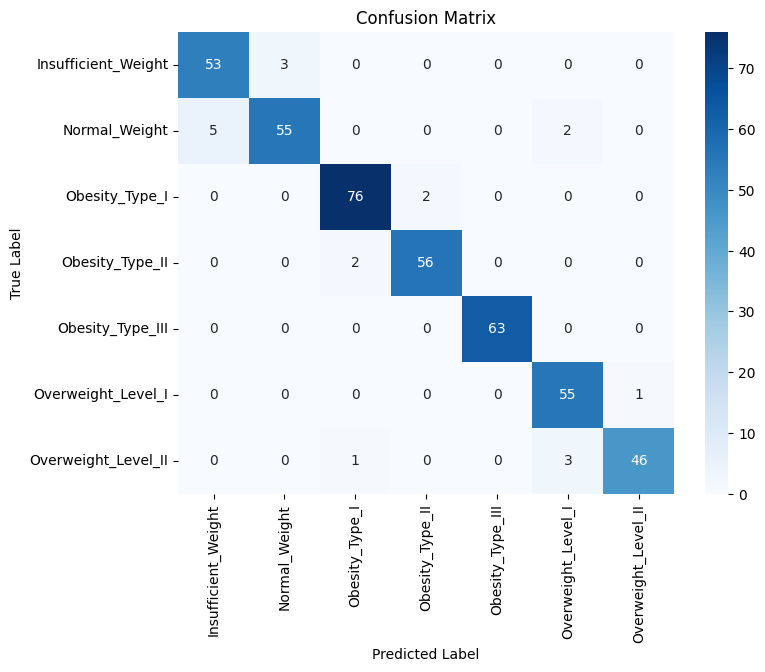

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Métricas de Decisión

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (Weighted): {precision:.4f}")
print(f"Recall (Weighted): {recall:.4f}")
print(f"F1-Score (Weighted): {f1:.4f}")

Accuracy: 0.9551
Precision (Weighted): 0.9557
Recall (Weighted): 0.9551
F1-Score (Weighted): 0.9550


## Plot del Árbol

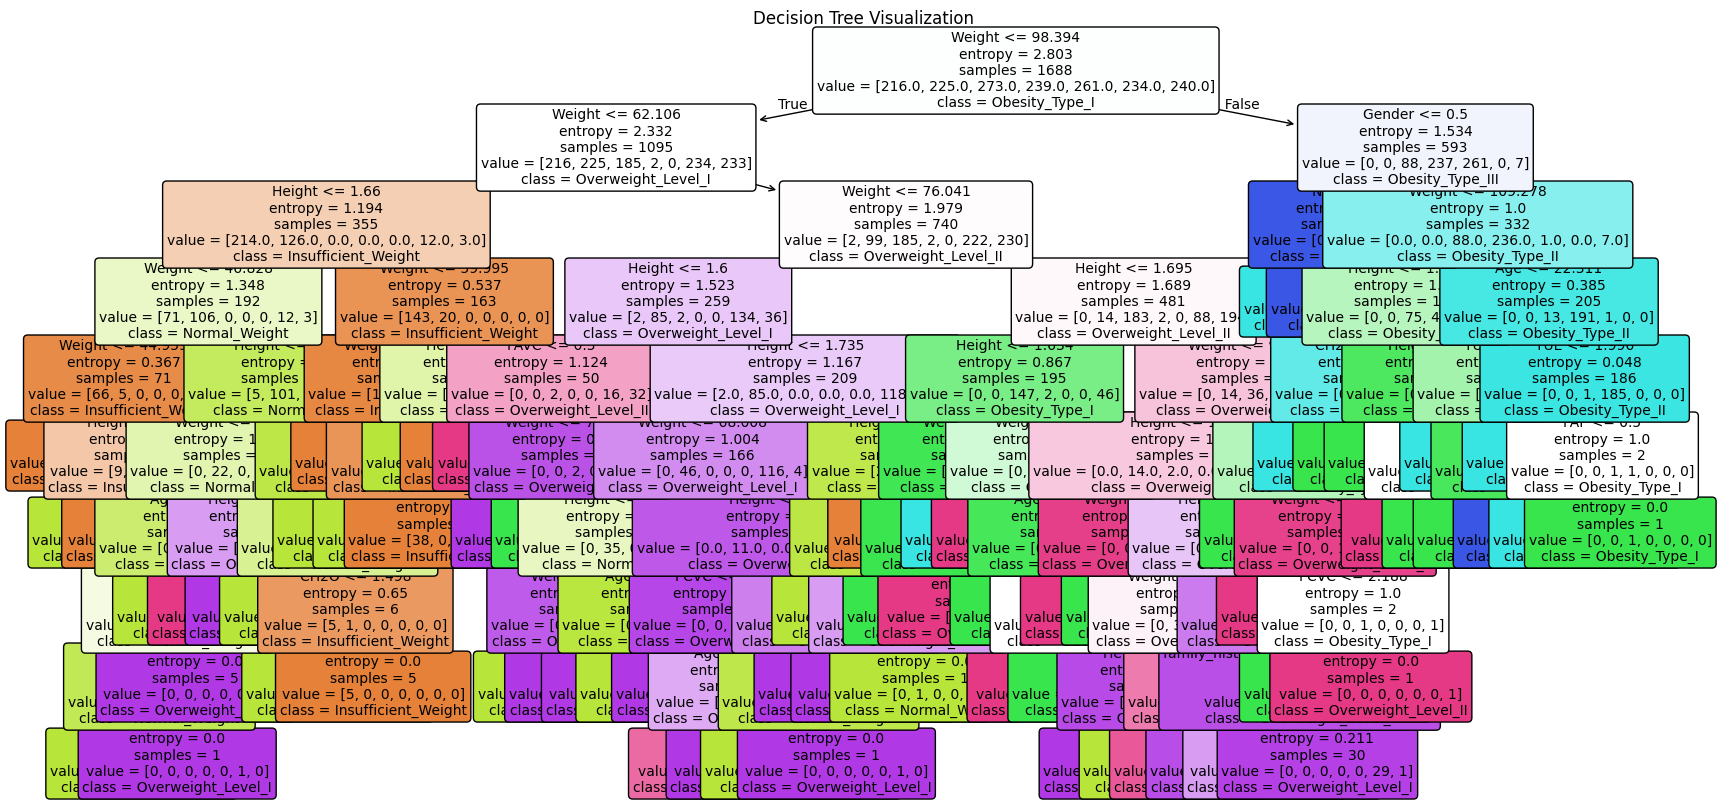

In [ ]:
plt.figure(figsize=(20, 10))

# Plot the tree
plot_tree(
    clf,          # Your trained DecisionTreeClassifier object
    feature_names=X.columns,  # Names of the features in your dataset
    class_names=clf.classes_,  # Names of the target classes
    filled=True,  # Fill nodes with colors to indicate the majority class
    rounded=True, # Round the corners of the nodes
    fontsize=10   # Adjust font size for readability
)

plt.title('Decision Tree Visualization')
plt.show()

## Verificación con Cross Validation

In [ ]:
clf_cv = DecisionTreeClassifier(criterion = 'entropy', max_depth = 9, random_state = 42)


# Perform cross-validation with stratified splits
cv_scores = cross_val_score(clf_cv, X, Y, scoring='accuracy')

# Print the cross-validation scores
print("Cross-validation Accurcay Scores:", cv_scores)
print("Mean Cross-validation Accuracy:", cv_scores.mean())
print("Standard Deviation of Cross-validation Accurcay:", cv_scores.std())

Cross-validation Accurcay Scores: [0.86052009 0.94549763 0.94312796 0.93838863 0.96208531]
Mean Cross-validation Accuracy: 0.9299239241257997
Standard Deviation of Cross-validation Accurcay: 0.035608381846799333


## Conclusión de Predicción del Árbol

3. Finalmente para conocer si los resultados obtenidos por el modelo estaban correctos se realizó la impresión de la matriz de confusión y se utilizaron todas las métricas a nuestro alcance, de las cuáles el árbol consiguió métricas considerablemente adecuadas y hasta excelentes. Teniendo:

Accuracy: 0.9551

Precision (Weighted): 0.9557

Recall (Weighted): 0.9551

F1-Score (Weighted): 0.9550

Ahora, estas métricas, debido a que la clase a predecir es categórica, resultaron en un promedio de todas las métricas respectivas de sus subclases. Sin embargo el promedio no pierde información relevante pues como se observa dentro de la matriz de confusión todas las clases cuenta con una paridad y similaridad con respecto a los datos que clasifican y no existe ninguna clase que se esté sobrestimando dentro de este análisis.

Asimismo, si quisiéramos guiarnos tan solo por una clase la indicada sería la clase de Recall pues me parece más adecuado prestar atención a los Falsos Negativos, de manera que ninguna persona con algún tipo de obesidad pueda pasar desapercibida y se le de el manejo medico y especializado correspondiente.







# K-Means

## Recategorización

1. Indica cuáles atributos (columnas) quitaras del dataset para que los datos no tengan algún tipo de etiqueta de clasificación

Muchos de los datos dentro del dataset cuentan con un tipo de calsificación que podría llegar a ser tomada para la predicción supervisada, sin embargo tenemos que tomar en cuenta las limitaciones dimensionales de K-Means y su ontología como no supervisado. Por lo que quitaré todas las columnas salvo por 3 relevantes, Peso, altura, y edad, considero que estas 3 son capaces de arrojar una clasificación demográfica interesante de los datos en un algoritmo de k_Means con 3 dimensiones. Evidentemente siguiendo la lógica disponible con entidades matemáticas como el índice de masa corporal y otros estudios que clasifican de esta manera. Asimismo se realizo un scatter plot de estos datos que dejan observar algún tipo de categorización interesante de los datos que se subdivide en capaz, por lo que podrían llegar a ser tanto epistemológicamente (por el tipo de dataset que se tiene) como teóricamente por el tipo de scatter que generan, una clasificación demográfica oinrteresabte para realizar con este algoritmo.

In [ ]:
kdf = df[['Age', 'Height', 'Weight']]
kdf.head()

,Age,Height,Weight
0,21.0,1.62,64.0
1,21.0,1.52,56.0
2,23.0,1.80,77.0
3,27.0,1.80,87.0
4,22.0,1.78,89.8


## Scatter de Datos Brutos

In [ ]:
fig = px.scatter_3d(kdf, x='Age', y='Height', z='Weight',
                    title='3D Scatter Plot of Age, Height, and Weight')
fig.show()

## Creación del KMeans




2. Indica cuáles hiperparámetros, y qué valores, utilizarás para realizar el entrenamiento

Los hiperparámetros utilizados para este algoritmo de K-Means son:

init="random": Que nos ayuda a inicializar el primer punto a partir del cual se comienza a generar el algoritmo de clustering.

n_clusters=2: Cantidad de Clusters a subdividir los datos planteados.


n_init=12 : Número de inicializaciones diferentes de las cuales se cálcula la inercia  de los clusters para evitar quedarnos atascados en un mínimo local o una clasificación que no nos ayude con nuestros propósitos. Se eligió 12 porque es un valor considerablemente decente que no derrocha poder computacional y es capaz de considerar unas cuantas incializaciones diferentes como para poder elegir algo que no siempre esté en un máximo local.


max_iter=480: Solamente la cantidad de iteraciones que se tienen que seguir para el proceso de clustering, es decir para encontrar los centroides finales y los puntos que pertencen a cada uno. 480 para asegurar que se encuentra un centroide decente.


Y la semilla de random state no la modificamos, directamente solo dejamos el predeterminado heredado por la clase de k-means.

In [ ]:
kmeans = KMeans(
init="random",
n_clusters=2,
n_init=12,
max_iter=480,
)

kmeans.fit(kdf)

KMeans(init='random', max_iter=480, n_clusters=2, n_init=12)

## Graficación del Cluster Basada en Colores

3.a. ¿El resultado que te arroja el entrenamiento hace algún sentido? ¿A qué tipo de clases/datos se refieren los conjuntos obtenidos?


Si, hace sentido el resultado arrojado en primera instancia. Podemos observar desde que se graficaron los datos en un scatter tridimensional por primera vez que la mayoría de los datos se estratificaban en pór capaz en función del parámetro de peso,m cosa que hacía coherencia, pero, ahora, con 2 clusters ya se nos da una estratificación dicotómica que nos permite intuir gracias a los ejes dimensionales que tienen que está haciendo una partición binaria que clasifica a quienes tienen desde una proporción de altura, peso, edad relativamente cercana al estado matemáticamente óptimo dado por estos datos contra la parte superior del clustering que contiene a todos aquellos con un índice desproporcionado en este sentido u obeso si ya se omiten ontologías matemáticas de los datos, es decir, que el segundo cluster cuenta con la gente que tiene desde una obesidad media-considerable hasta los casos de obesidad más significativos o tipo 3.

In [ ]:
kdf_clustered = kdf.copy() # Copia del modelo para poder modificar sin problema
kdf_clustered['Cluster'] = kmeans.labels_ # Nueva columna para asignar colores con cada etiqueta

# Plot en 3d con colores bonitos
fig = px.scatter_3d(kdf_clustered, x='Age', y='Height', z='Weight',
                    color='Cluster', # La nueva columna para signar colores
                    title='3D Scatter Plot of Age, Height, and Weight Clustered')
fig.show()

# Resultados Generales
print("Inertia: ", kmeans.inertia_)
print("Cluster Center: ", kmeans.cluster_centers_)
print("Cycles: ", kmeans.n_iter_)
print("First 5 labels: ", kmeans.labels_[:5])

Inertia:  494578.60236016486
Cluster Center:  [[ 23.5731989    1.6749903   68.84223719]
 [ 25.46516923   1.74327681 114.24491113]]
Cycles:  10
First 5 labels:  [0 0 0 0 0]


3.b. ¿Podrías mejorar el resultado del entrenamiento? ¿Cómo?
Si, podemos revisar con ayuda de una gráfica de codo cuál sería la cantidad de clusters más adecuada para tomar en consideración una reducción de la inercia de los datos. En este sentido podemos intuir tan solo a partir de observar las clasificaciones de los datos que la cantidad óptima de clusters debería de ser 4 para poder clasificar la obesidad tipo 1, 2, 3 y clasificar a los que cuentan con un peso no obeso y "normal" indicaría el dataset.

## Gráfica de Codo

In [ ]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 400,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(kdf)
    sse.append(kmeans.inertia_)

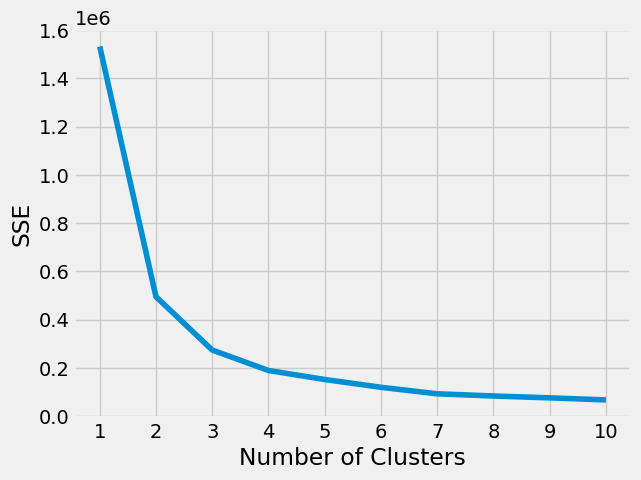

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

## Nuevo Cluster K = 4

In [ ]:
kmeans = KMeans(
init="random",
n_clusters=4,
n_init=12,
max_iter=480,
)

kmeans.fit(kdf)

KMeans(init='random', max_iter=480, n_clusters=4, n_init=12)

## Graficación Definitiva

In [ ]:
kdf_clustered = kdf.copy() # Copia del modelo para poder modificar sin problema
kdf_clustered['Cluster'] = kmeans.labels_ # Nueva columna para asignar colores con cada etiqueta

# Plot en 3d con colores bonitos
fig = px.scatter_3d(kdf_clustered, x='Age', y='Height', z='Weight',
                    color='Cluster', # La nueva columna para signar colores
                    title='3D Scatter Plot of Age, Height, and Weight Clustered')
fig.show()

# Resultados Generales
print("Inertia: ", kmeans.inertia_)
print("Cluster Center: ", kmeans.cluster_centers_)
print("Cycles: ", kmeans.n_iter_)
print("First 5 labels: ", kmeans.labels_[:5])

Inertia:  188697.41108737793
Cluster Center:  [[ 20.90697537   1.65057551  55.22262182]
 [ 26.36720578   1.72028551 107.45572122]
 [ 23.39413541   1.78964264 130.34614831]
 [ 25.83961756   1.6975119   80.54360652]]
Cycles:  12
First 5 labels:  [0 0 3 3 3]




3.c. Realiza la mejora y compara los 2 resultados obtenidos utilizando este método No Supervisado.


3.c.1. ¿Cuál fue el mejor resultado?
Definitivamente el segundo. De por sí era bastante predecible el tipo de clustering con 4 categorías, la gráfica de codo generada nos indicó todavía más fuertemente que en el punto de 4 se quebraba la inertia para obtener un máximo de clasificación de datos e inercia. Asimismo, al graficar ambos conjuntos podemos observar menos una masa amorfa calsificada por densidad y es muy visible, hasta claro, el tipo de laminaridad presente en la distirbución de nuestros datos.


Entonces, la gráfica es visiblemente mejor categorizada. La dimensionalidad de nuestros datos tiene sentido basándonos en el contexto de clasificación, es decir, que su laminaridad asciende espacialmente a través del eje dimensional del peso y nos permite ver con claridad nefaste la partición de los datos dentro de las 4 categorías que desde un inicio corresponden perfectamente con la categorización que utilizamos, la columna de NObeseydad que nos daba de por sí 4 categorías, "normal", diabetes 1,2,3". Es decir, me parece que si bien la clasificación no es perfecta y ha de contar con outliers en algún punto es posible observar que el segundo modelo que hace lo mismo que el primero, es sin embargo todavía mejor en la clasificación y partición de nuestros datos para su posterior organización